## Signal manipulation: shift a complex IQ passband signal to a complex IQ baseband signal (and vice versa)

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import scipy.fft as spfft

In [2]:
# Interactive plotting.  Comment out this next line if inline plots are desired.
%matplotlib qt

In [3]:
# Function to create IQ representation of sine wave at a given freq for a given sample rate.
#
# Inputs: 
#  freq - frequency of sine wave, Hz
#  amp  - amplitude, arbitrary units
#  fs   - sampling rate of sine wave, Hz
#  no_samps - number of samples to generate
#
# Returns:
#  complex (IQ) representation of sine wave with input parameters.
#
# Affects: None
#
# Exceptions: AssertionError if freq >= fs.
#
def create_sig(freq, amp, fs, no_samps):
    assert freq < fs
    delta_t = 1.0 / fs
    x = np.linspace(0.0, no_samps * delta_t, no_samps, endpoint=False)
    iq = amp * np.exp(1j * freq * 2.0 * np.pi * x)
    return iq

In [4]:
# Function to plot the frequency domain spectrum of a complex signal.
#
# Inputs: 
#  y - complex time domain signal to be plotted
#  fs - sampling rate, Hz
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max)  None=autoscale
#  ylim - y axis plot limits: (min, max)  None=autoscale
#
# Returns:
#  Plot of frequency domain representation of signal.
#
# Affects: None
#
# Exceptions: None
#
def spec_plot(y, fs, ttext, xlim=None, ylim=None):
    delta_t = 1.0 / fs
    no_samps = len(y)
    yf = spfft.fft(y)
    xf = spfft.fftfreq(no_samps, delta_t)
    xf_shift = spfft.fftshift(xf)
    yf_shift = spfft.fftshift(yf)
    plt.figure()
    plt.plot(xf_shift, 1.0/no_samps * np.abs(yf_shift))
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.xlabel('Frequency, Hz')
    plt.ylabel('Spectral amplitude')
    plt.title(ttext)
    plt.grid()
    plt.show()

In [5]:
fs = 32000       # sample rate
no_samps = 32000 # number of samples
cf = 10000       # center frequenccy

In [6]:
# 4 signal frequencies with different amplitudes
sig_1_f = 8000
sig_1_a = 0.7
sig_2_f = 9000
sig_2_a = 0.8
sig_3_f = 11000
sig_3_a = 0.9
sig_4_f = 12000
sig_4_a = 1.0

In [7]:
# create signals individually
sig_1 = create_sig(sig_1_f, sig_1_a, fs, no_samps)
sig_2 = create_sig(sig_2_f, sig_2_a, fs, no_samps)
sig_3 = create_sig(sig_3_f, sig_3_a, fs, no_samps)
sig_4 = create_sig(sig_4_f, sig_4_a, fs, no_samps)
# sum them to create input complex signal
sig = sig_1 + sig_2 + sig_3 + sig_4

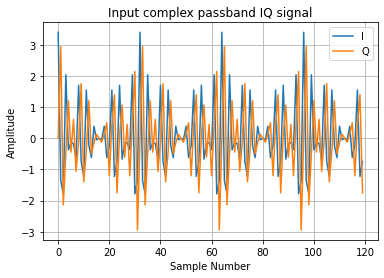

In [8]:
# plot 120 samples of time series before filter
plt.figure()
plt.plot(np.real(sig[0:120]),label='I')
plt.plot(np.imag(sig[0:120]),label='Q')
plt.legend()
plt.grid()
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.title('Input complex passband IQ signal')
plt.show()

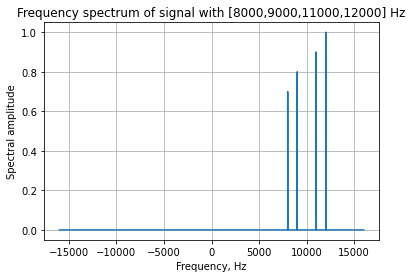

In [9]:
# plot spectrum of four baseband signals
spec_plot(sig, fs, 
          'Frequency spectrum of signal with [%.0f,%.0f,%.0f,%.0f] Hz' % (sig_1_f, sig_2_f, sig_3_f, sig_4_f))

In [10]:
# shift to baseband by multiplying (mixing) by another frequency shifted signal
#
# freq_shift_down = distance that freqs are shifted (NB: not what center frequency becomes after the shift)
#
# Examples:
#  shift fc to fb: set freq_shift_down to (fc - fb)
#  shift so fc is zero: e.g. fc -fb = 10000 - 0 = 10000 so set freq_shift_down to 10000
#  shift so fc is -1000 Hz: fc - (-1000) = 10000 + 1000 so set freq_shift_down to 11000
#
# Question to the reader: 
#   Complex multiplication does not create two output frequencies at (fc +/- fb), like a
#   normal mixer mixing two real domain signals together.  Why?
#   (Think about difference between real and complex signals)
#

# Choose to shift the frequency to zero
freq_shift_down = cf # shift to be centered at 0 Hz
shift_down = create_sig(-freq_shift_down, 1, fs, no_samps)
base_band_sig = sig * shift_down

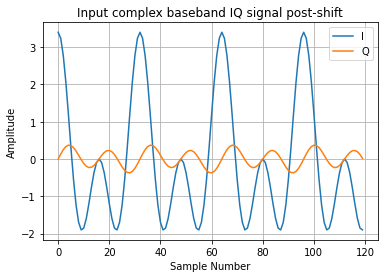

In [11]:
# plot 120 samples of time series after downshifting operation
plt.figure()
plt.plot(np.real(base_band_sig[0:120]),label='I')
plt.plot(np.imag(base_band_sig[0:120]),label='Q')
plt.legend()
plt.grid()
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.title('Input complex baseband IQ signal post-shift')
plt.show()

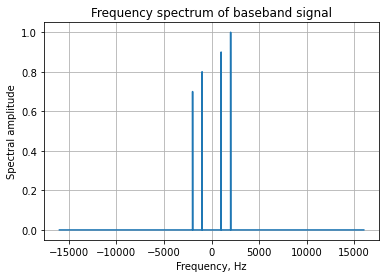

In [12]:
# plot spectrum after shift to base band
spec_plot(base_band_sig, fs, 
          'Frequency spectrum of baseband signal')

In [13]:
# shift base band signal back up to a center frequency of 10000 Hz
# (similar technique)
freq_shift_up = -cf # notice the minus sign!
shift_up = create_sig(-freq_shift_up, 1, fs, no_samps)
pass_band_sig = base_band_sig * shift_up

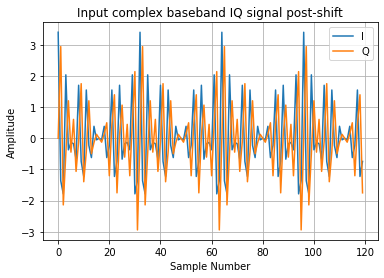

In [14]:
# plot 120 samples of time series after shifting operation
plt.figure()
plt.plot(np.real(pass_band_sig[0:120]),label='I')
plt.plot(np.imag(pass_band_sig[0:120]),label='Q')
plt.legend()
plt.grid()
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.title('Input complex baseband IQ signal post-shift')
plt.show()

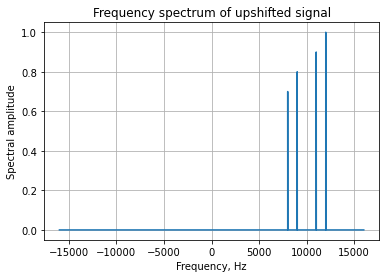

In [15]:
# plot spectrum after shift up
spec_plot(pass_band_sig, fs, 
          'Frequency spectrum of upshifted signal')